#### IMPORT REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set style for professional visualizations
#plt.style.use('seaborn-v0_8')
#sns.set_palette("husl")

#### DATA ACQUISITION

Going ahead with cleveland data only as it is the most proper data available in the UCI repo. Other than cleveland data, all opther data seems to be very raw.

In [2]:
print("🔄 Loading and Preprocessing Data...\n")

file_path = r'C:\WILP 3rd sem\MLOps\Assignment_01\heart+disease\processed.cleveland.data'

column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
                'restecg', 'thalach', 'exang', 'oldpeak', 
                'slope', 'ca', 'thal', 'target']

# Load the dataset
df = pd.read_csv(file_path, header=None, names=column_names)   #header=None: Tells pandas that the first row is NOT column names, The file contains only raw data (numbers), no header row. names=col_names: Manually assigns the column names you provide in the list col_names, Without this, columns would be named 0, 1, 2, ..., 13, which is hard to work with.

print(f"✅ Dataset Loaded Successfully!")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")


🔄 Loading and Preprocessing Data...

✅ Dataset Loaded Successfully!
Shape: 303 rows and 14 columns



#### PREPROCESS THE DATASET

In [3]:
         
df = df.replace('?', np.nan)                      #Replaces every '?' with NaN (Not a Number), which is pandas' standard way of representing missing data. In the UCI Heart Disease dataset, missing values are represented by the character '?' (question mark). Pandas treats '?' as a string, which creates problems later
df = df.apply(pd.to_numeric, errors='coerce')     #pd.to_numeric: Converts string/object columns into numeric type. errors='coerce': If any value cannot be converted to a number (e.g., some unexpected text), it will be converted to NaN instead of throwing an error. 'coerce' = "force conversion and turn bad values into NaN". Even after replacing '?', some columns might still be of object (string) type.

print("\nMissing Values before Imputation:")
print(df.isnull().sum())

# Handle missing values (Imputation)
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

print("Missing Values After Imputation:")
print(df.isnull().sum().sum(), "missing values remaining\n")

# Create binary target 
df['target_binary'] = df['target'].apply(lambda x: 0 if x == 0 else 1)

print("Target Distribution (Original Multi-class):")
print(df['target'].value_counts().sort_index())
print("\nTarget Distribution (Binary):")
print(df['target_binary'].value_counts())


Missing Values before Imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
Missing Values After Imputation:
0 missing values remaining

Target Distribution (Original Multi-class):
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Target Distribution (Binary):
target_binary
0    164
1    139
Name: count, dtype: int64


#### EXPLORATORY DATA ANALYSIS(EDA)


EXPLORATORY DATA ANALYSIS

1. Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            303 non-null    float64
 1   sex            303 non-null    float64
 2   cp             303 non-null    float64
 3   trestbps       303 non-null    float64
 4   chol           303 non-null    float64
 5   fbs            303 non-null    float64
 6   restecg        303 non-null    float64
 7   thalach        303 non-null    float64
 8   exang          303 non-null    float64
 9   oldpeak        303 non-null    float64
 10  slope          303 non-null    float64
 11  ca             303 non-null    float64
 12  thal           303 non-null    float64
 13  target         303 non-null    int64  
 14  target_binary  303 non-null    int64  
dtypes: float64(13), int64(2)
memory usage: 35.6 KB
None

2. Statistical Summary:
          age     sex   

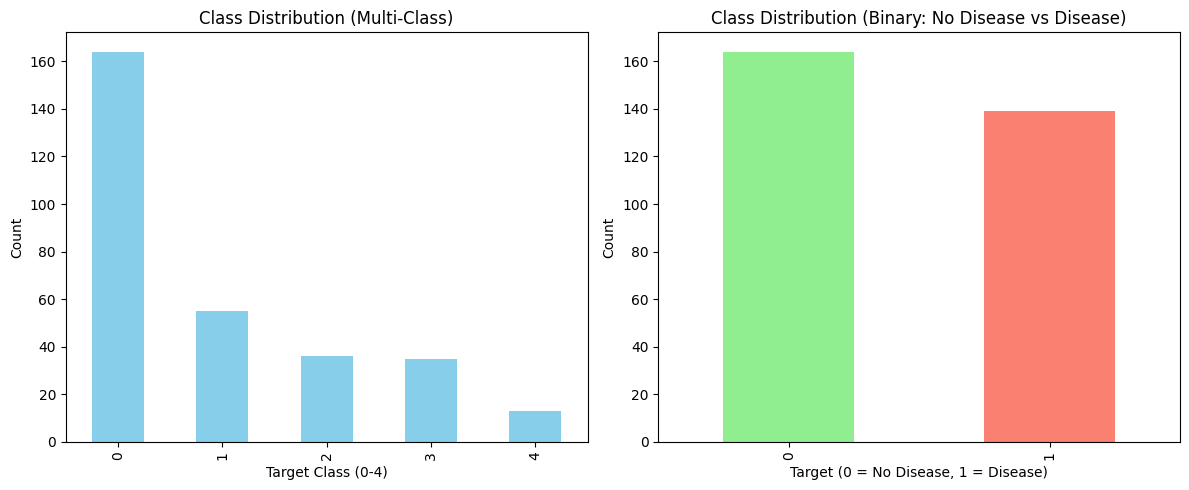

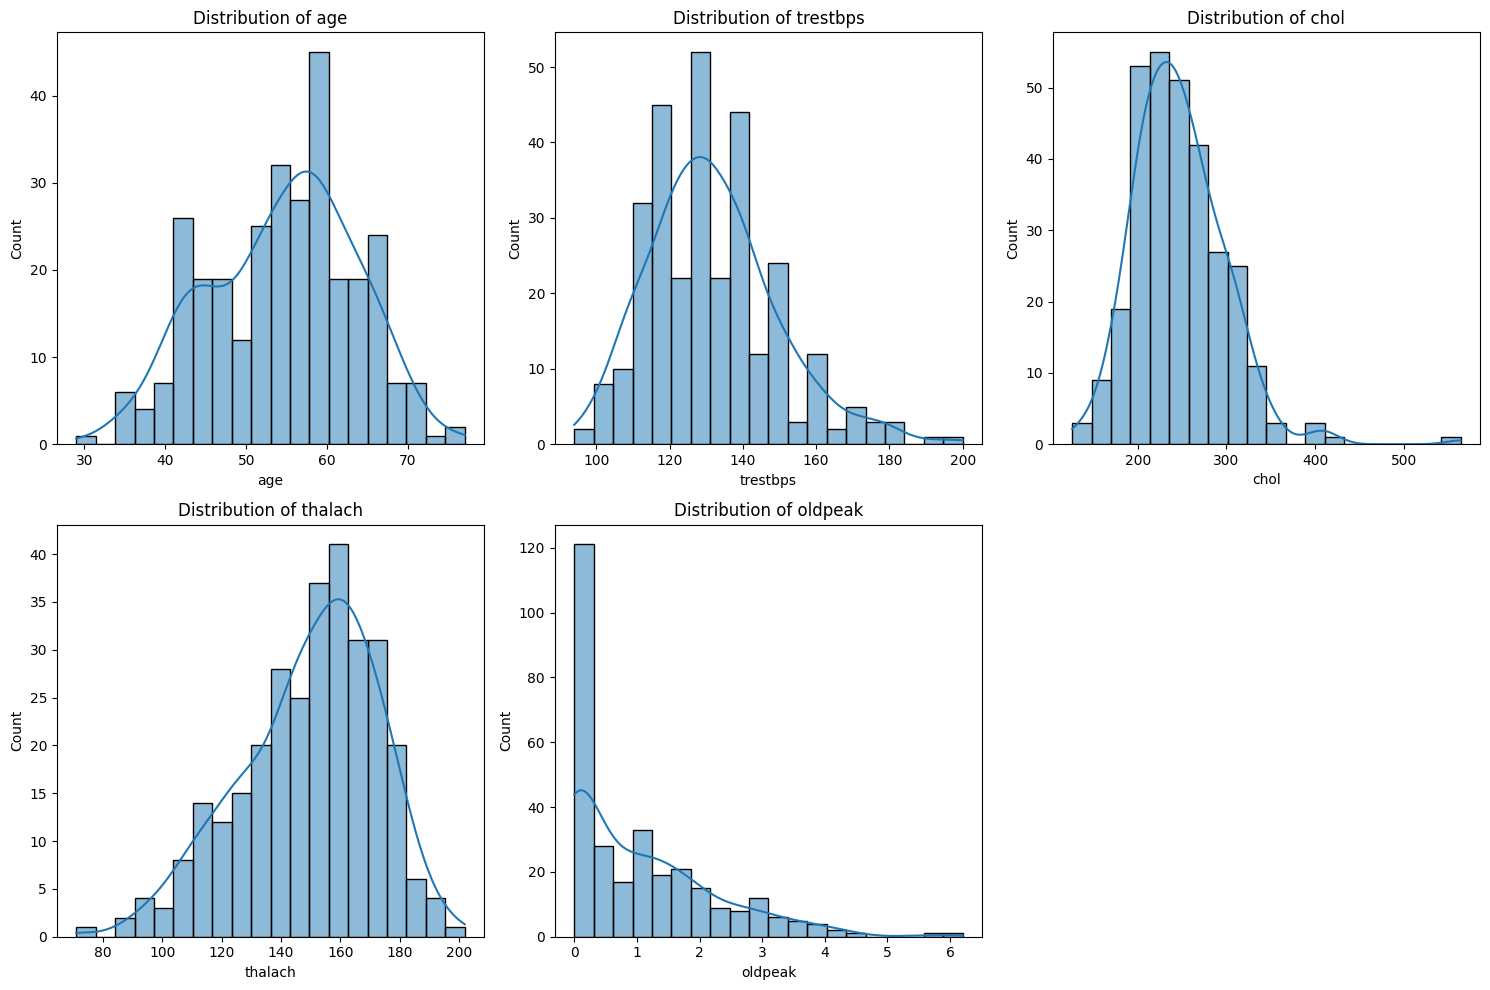

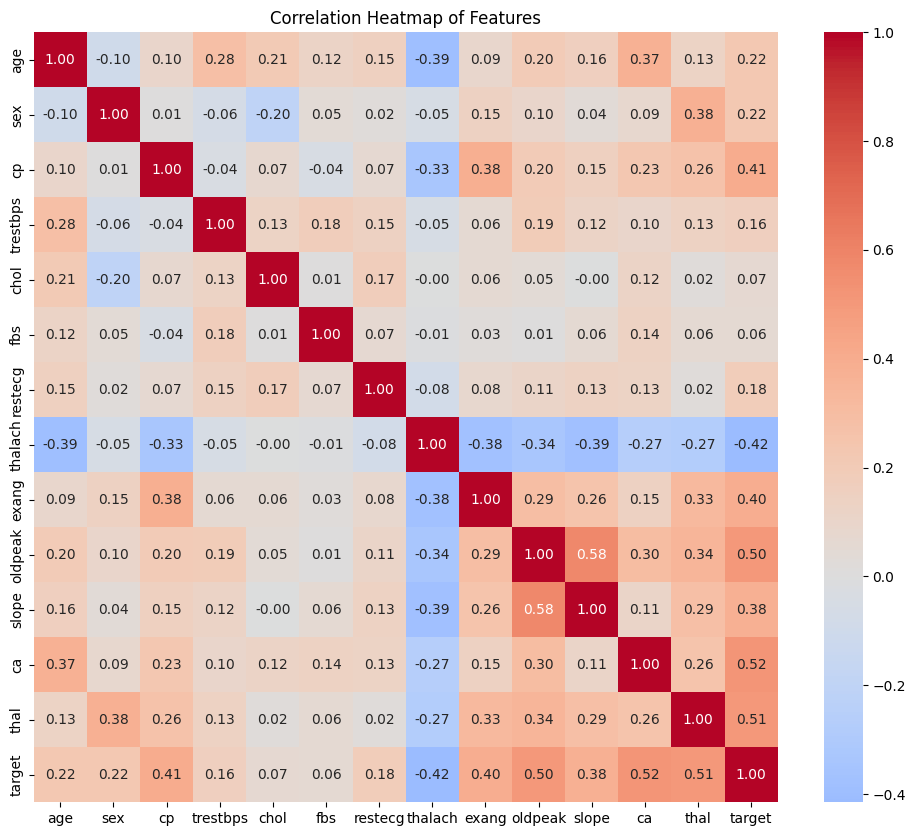

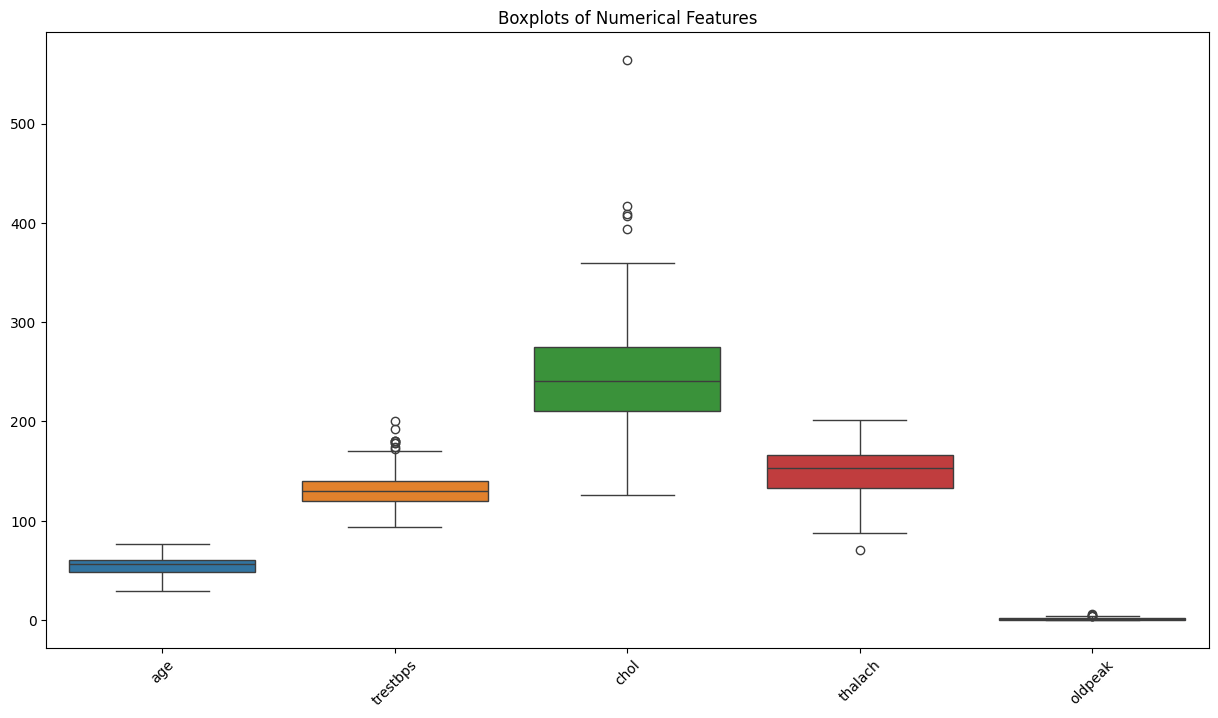

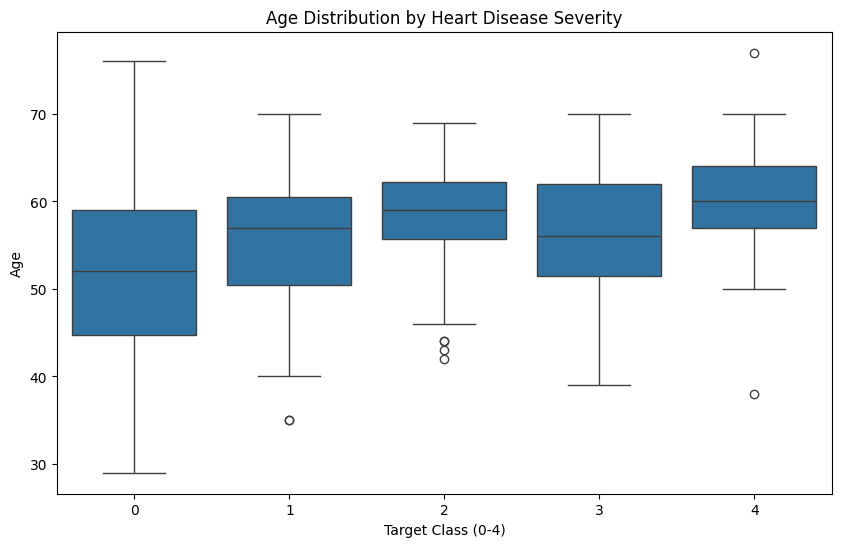


ADVANCED EXPLORATORY DATA ANALYSIS


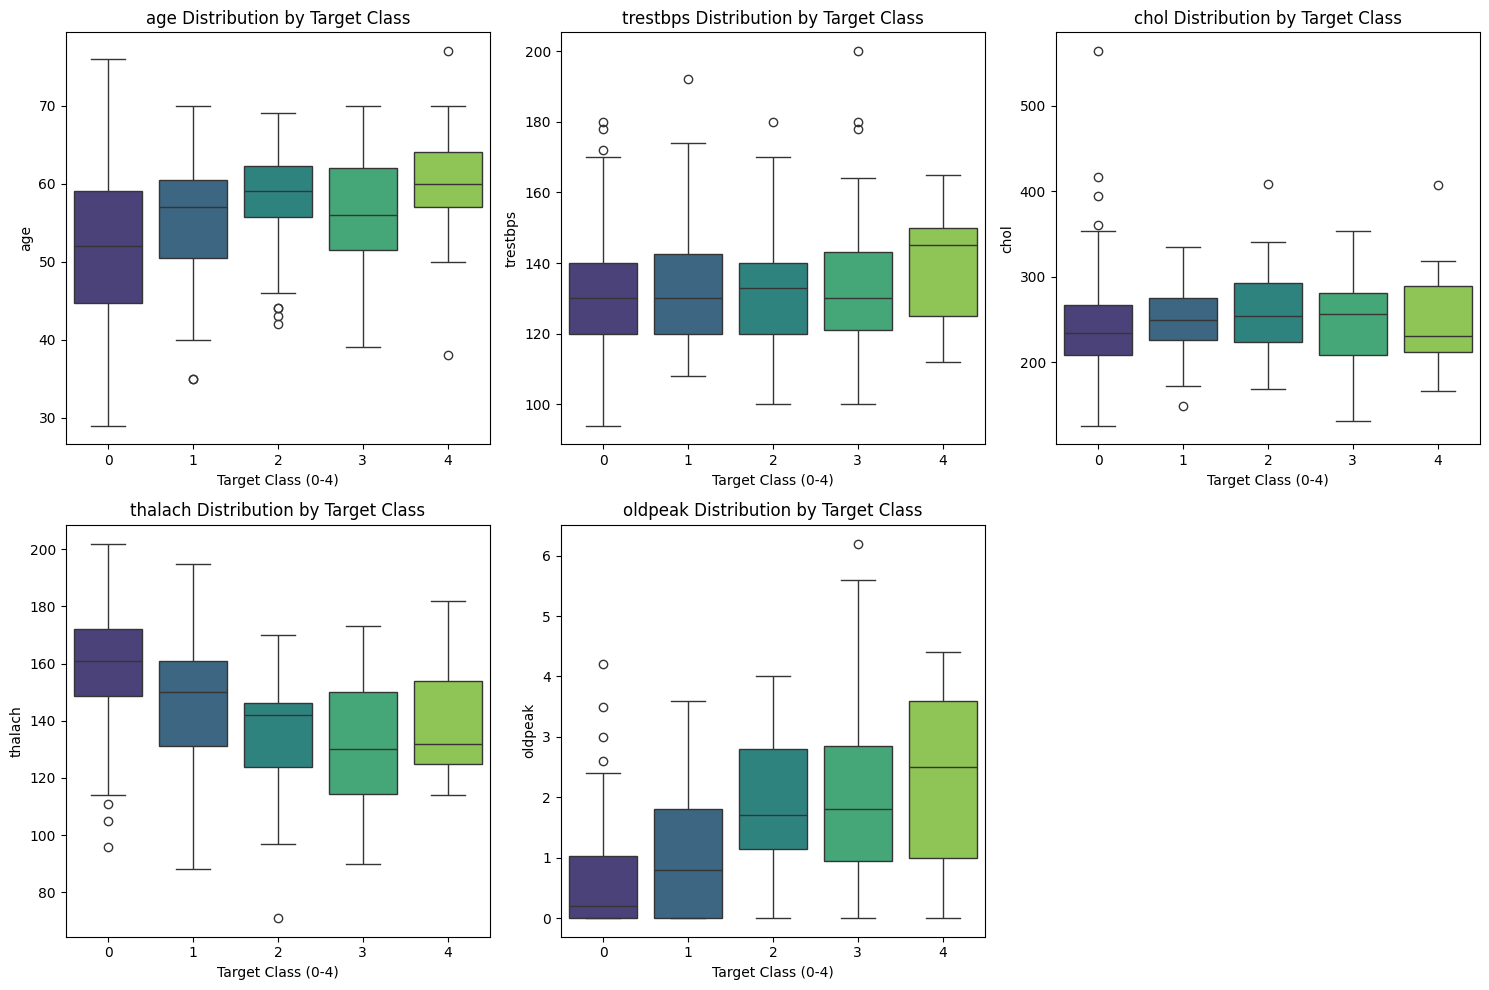

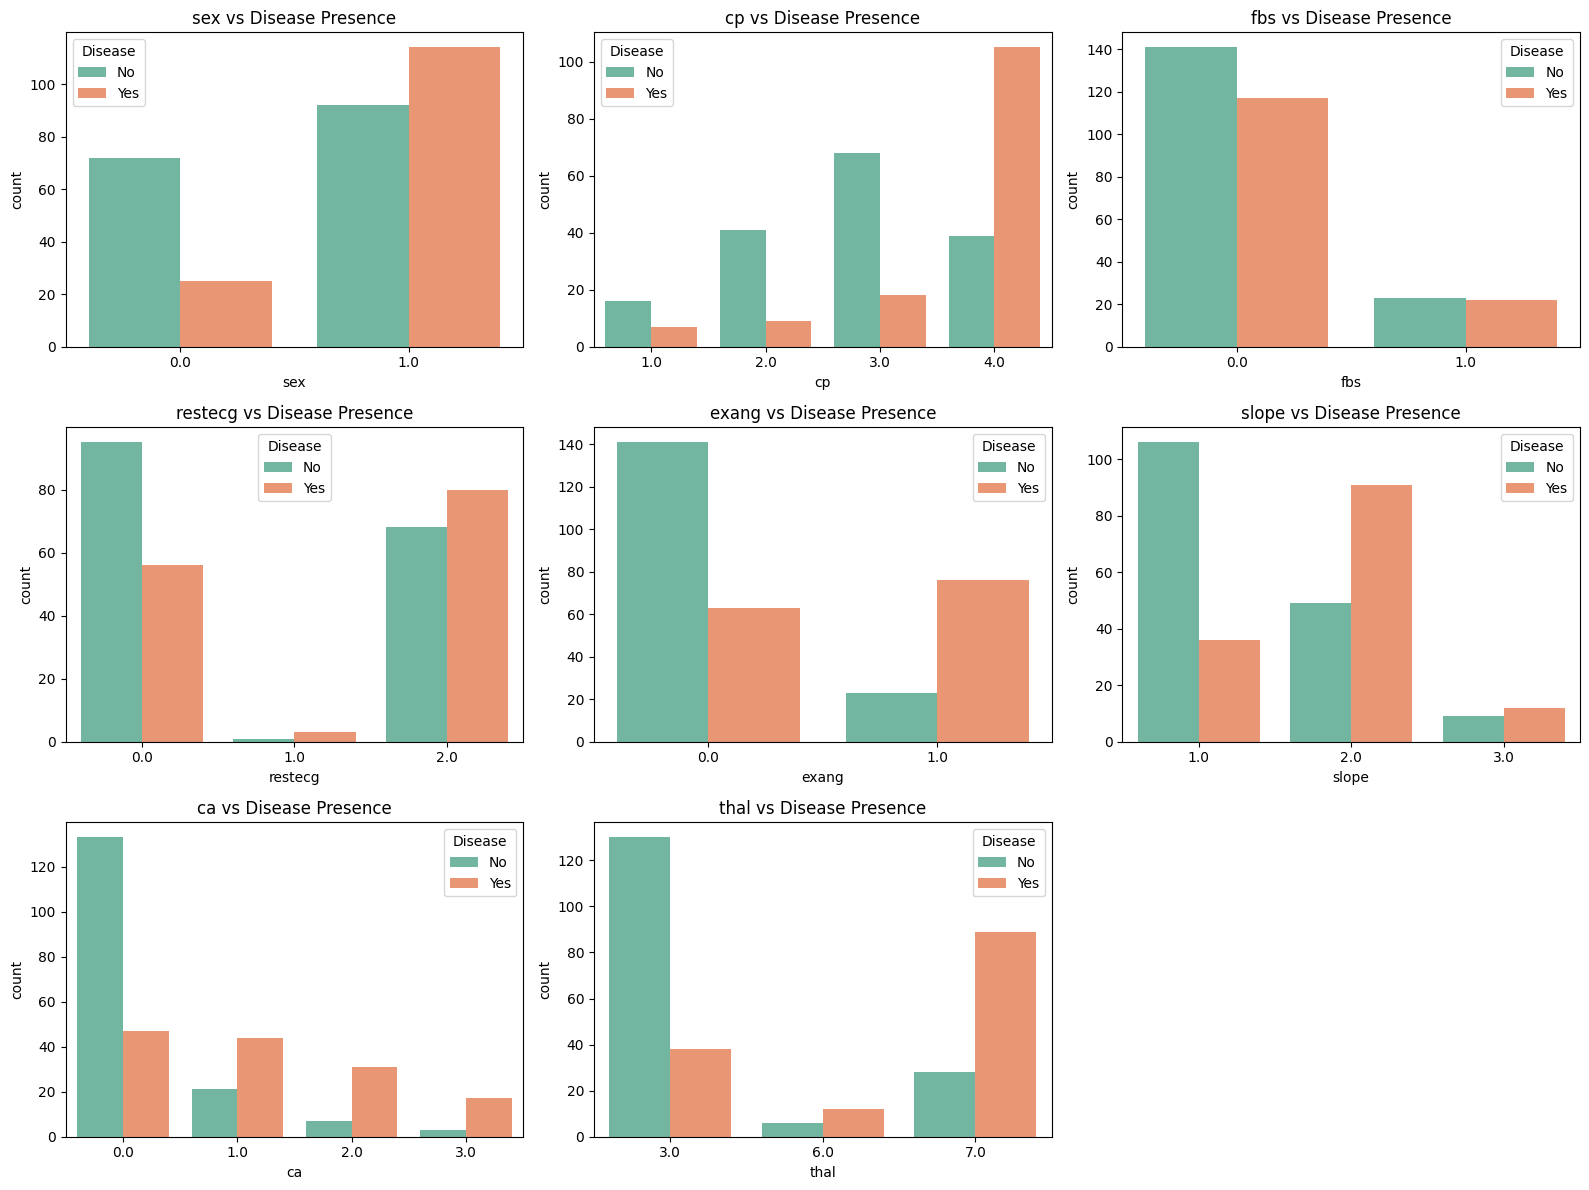

<Figure size 1200x1000 with 0 Axes>

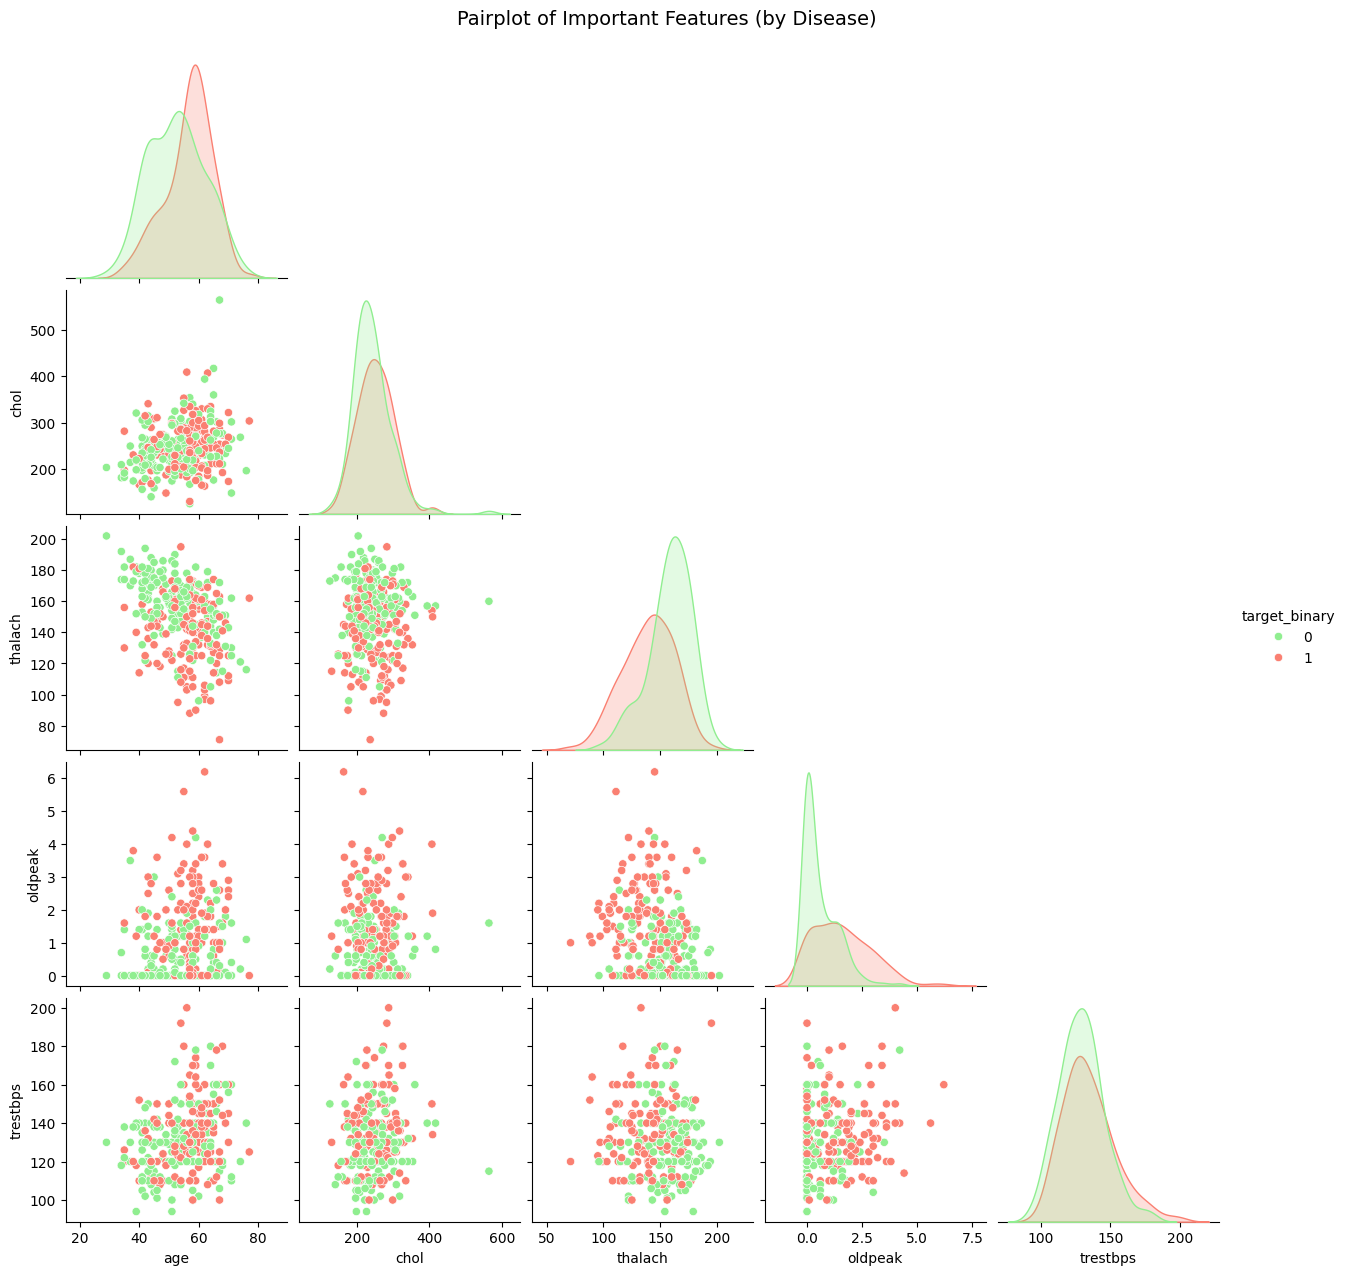

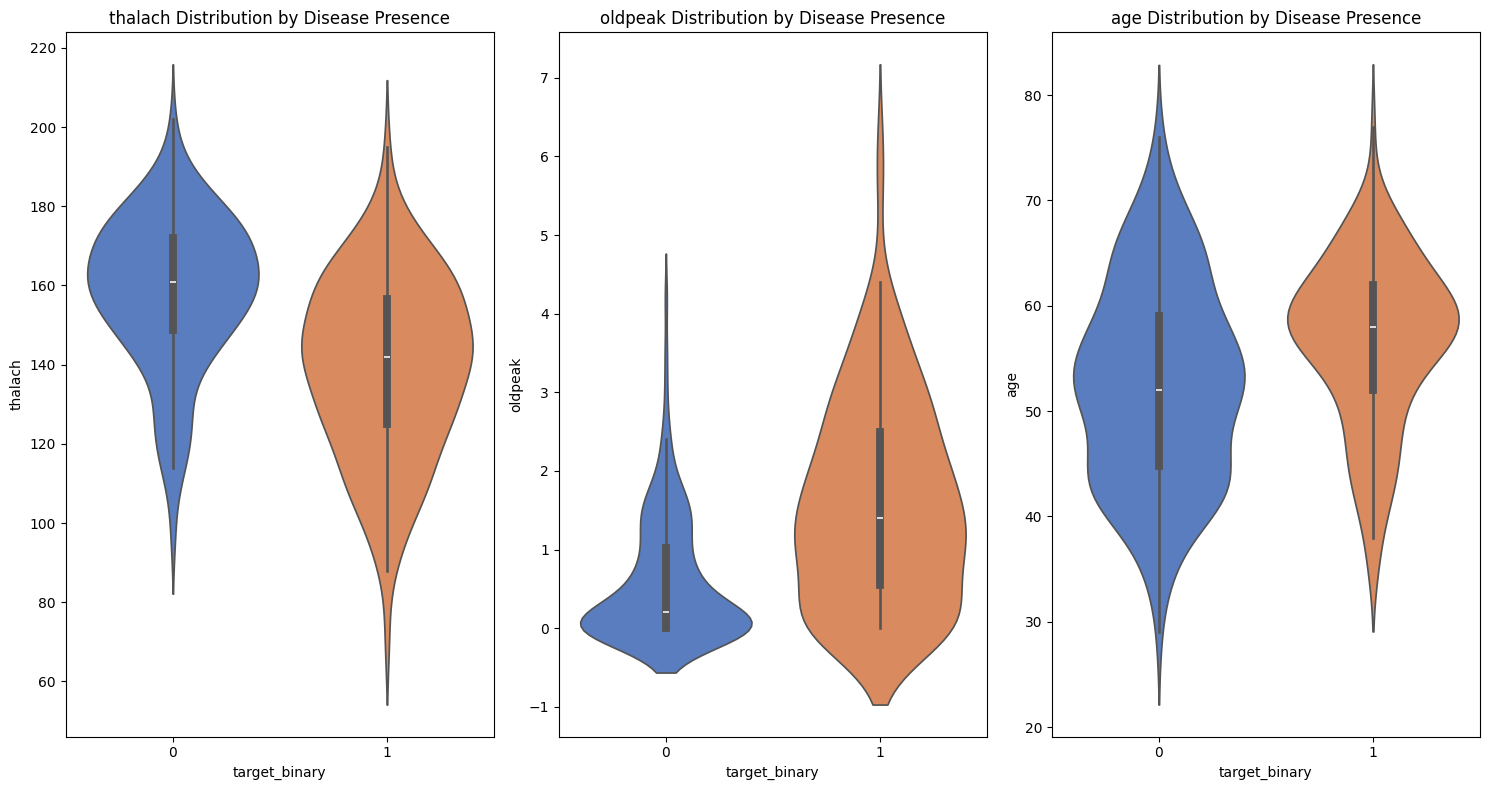

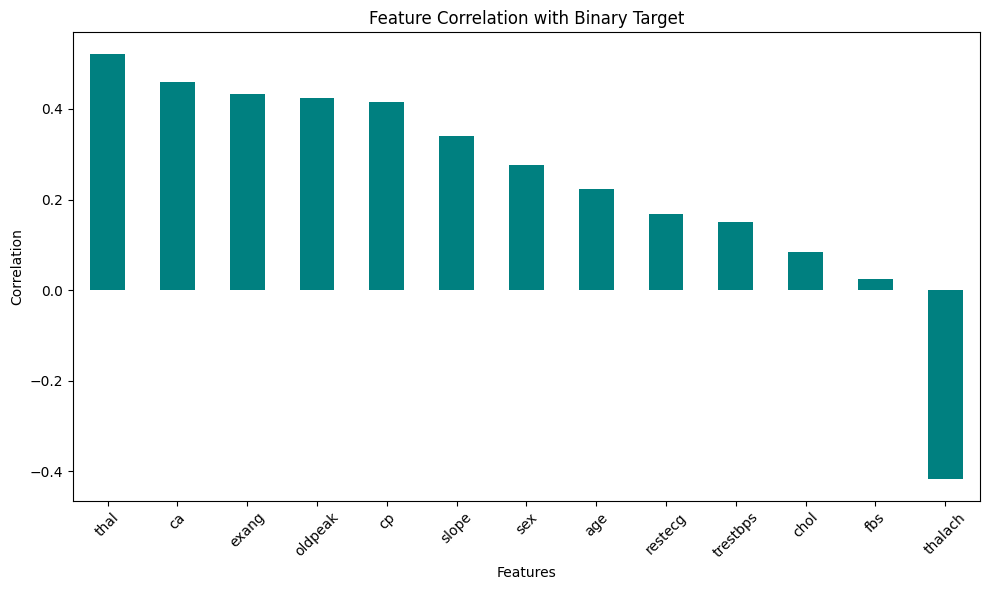


Skewness of Numerical Features:
oldpeak     1.270
chol        1.136
trestbps    0.706
age        -0.209
thalach    -0.537
dtype: float64

Kurtosis of Numerical Features:
chol        4.492
oldpeak     1.576
trestbps    0.880
thalach    -0.054
age        -0.523
dtype: float64

✅ Advanced EDA Completed!
Key Observations:
- Dataset contains 303 records and 14 features
- Only 6 missing values were handled using median imputation
- Strong class imbalance observed (Class 0 is dominant)


In [4]:
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# 3.1 Basic Information
print("\n1. Dataset Information:")
print(df.info())

print("\n2. Statistical Summary:")
print(df.describe().round(2))

# 3.2 Class Balance Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['target'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Class Distribution (Multi-Class)')
plt.xlabel('Target Class (0-4)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['target_binary'].value_counts().plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Class Distribution (Binary: No Disease vs Disease)')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# 3.3 Histograms of Numerical Features
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 3.4 Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.drop(['target_binary'], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

# 3.5 Boxplots (to detect outliers)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numerical_cols])
plt.title('Boxplots of Numerical Features')
plt.xticks(rotation=45)
plt.show()

# 3.6 Relationship between Age and Target
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='age', data=df)
plt.title('Age Distribution by Heart Disease Severity')
plt.xlabel('Target Class (0-4)')
plt.ylabel('Age')
plt.show()

# ====================== ADVANCED EDA ======================

print("\n" + "="*50)
print("ADVANCED EXPLORATORY DATA ANALYSIS")
print("="*50)

# 3.7 Boxplots of Numerical Features by Target Class (Advanced)
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='target', y=col, data=df, palette='viridis')
    plt.title(f'{col} Distribution by Target Class')
    plt.xlabel('Target Class (0-4)')
plt.tight_layout()
plt.show()

# 3.8 Categorical Features vs Target (Countplots)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='target_binary', data=df, palette='Set2')
    plt.title(f'{col} vs Disease Presence')
    plt.legend(title='Disease', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# 3.9 Pairplot of Key Features
selected_features = ['age', 'chol', 'thalach', 'oldpeak', 'trestbps', 'target_binary']
plt.figure(figsize=(12, 10))
sns.pairplot(df[selected_features], hue='target_binary', 
             palette=['lightgreen', 'salmon'], diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Important Features (by Disease)', y=1.02, fontsize=14)
plt.show()

# 3.10 Violin Plots (Distribution + Probability)
plt.figure(figsize=(15, 8))
for i, col in enumerate(['thalach', 'oldpeak', 'age'], 1):
    plt.subplot(1, 3, i)
    sns.violinplot(x='target_binary', y=col, data=df, palette='muted')
    plt.title(f'{col} Distribution by Disease Presence')
plt.tight_layout()
plt.show()

# 3.11 Feature-Target Correlation (Sorted)
plt.figure(figsize=(10, 6))
target_corr = df.drop(['target', 'target_binary'], axis=1).corrwith(df['target_binary']).sort_values(ascending=False)
target_corr.plot(kind='bar', color='teal')
plt.title('Feature Correlation with Binary Target')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3.12 Skewness Analysis
print("\nSkewness of Numerical Features:")
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print(skewness.round(3))

print("\nKurtosis of Numerical Features:")
kurtosis = df[numerical_cols].kurtosis().sort_values(ascending=False)
print(kurtosis.round(3))

print("\n✅ Advanced EDA Completed!")

print("Key Observations:")
print("- Dataset contains", df.shape[0], "records and 14 features")
print("- Only 6 missing values were handled using median imputation")
print("- Strong class imbalance observed (Class 0 is dominant)")

🔄 TASK 2: FEATURE ENGINEERING & MODEL DEVELOPMENT (Keras Neural Network)

1. Feature Engineering
Features shape: (303, 13)
Target distribution: [164 139]

Training set: 227 samples
Test set: 76 samples

2. Training Logistic Regression...

3. Training Random Forest...

4. Training Keras Neural Network (Dense Layers)...
Keras Neural Network training completed!

MODEL EVALUATION ON TEST SET

Logistic Regression
--------------------------------------------------
Accuracy : 0.8684
Precision: 0.8378
Recall   : 0.8857
F1-Score : 0.8611
ROC-AUC  : 0.9310

Confusion Matrix:
[[35  6]
 [ 4 31]]

Random Forest
--------------------------------------------------
Accuracy : 0.8684
Precision: 0.8205
Recall   : 0.9143
F1-Score : 0.8649
ROC-AUC  : 0.9275

Confusion Matrix:
[[34  7]
 [ 3 32]]

Keras Neural Network
--------------------------------------------------
Accuracy : 0.8684
Precision: 0.8571
Recall   : 0.8571
F1-Score : 0.8571
ROC-AUC  : 0.9366

Confusion Matrix:
[[36  5]
 [ 5 30]]


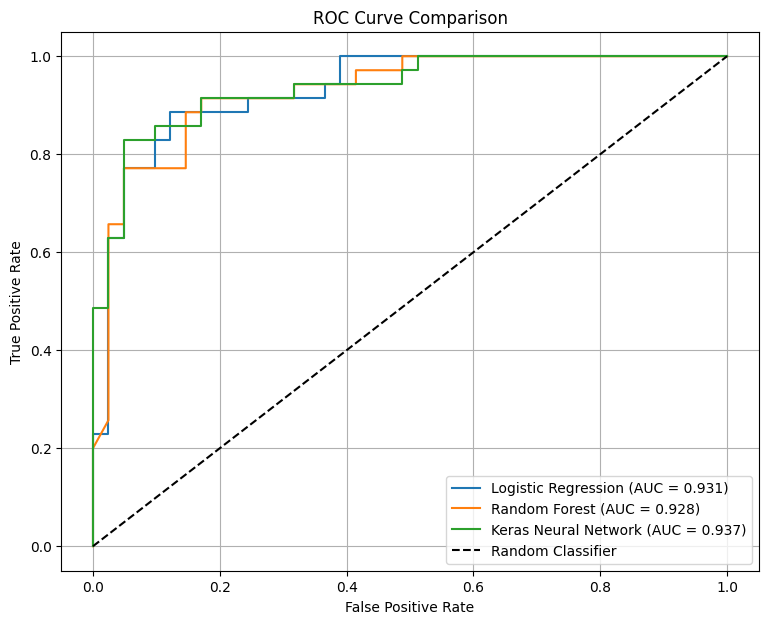

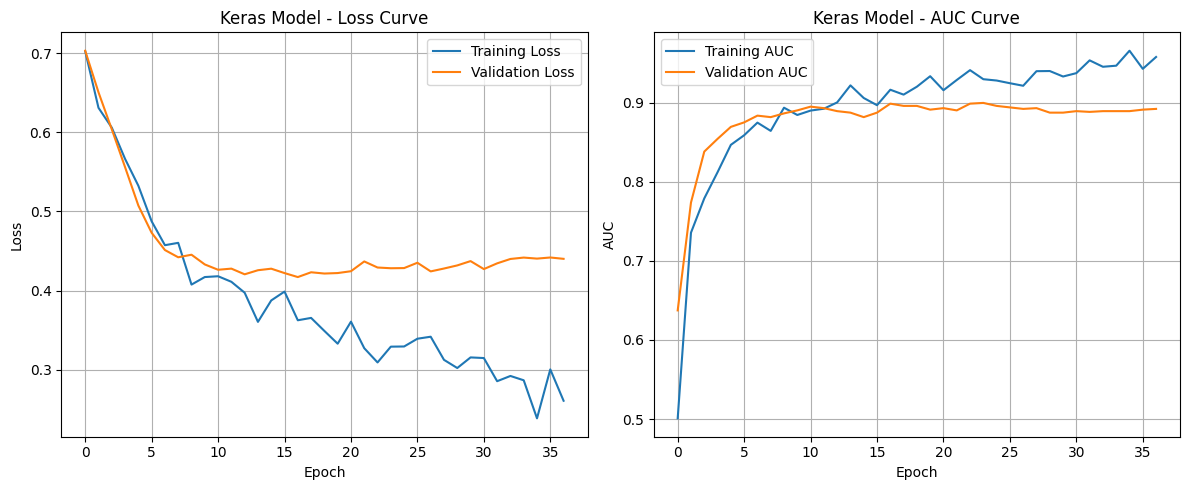

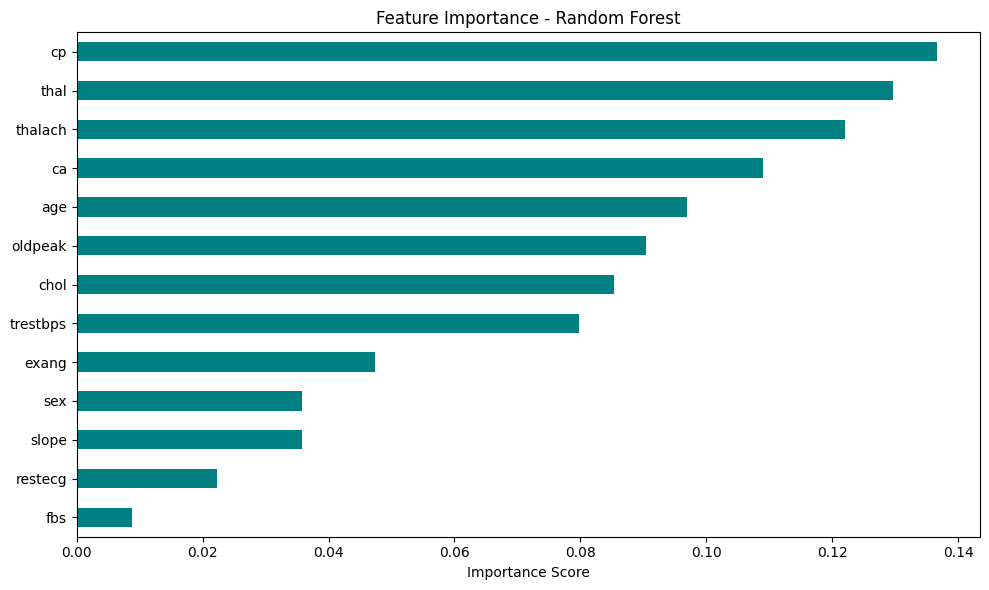


✅ TASK 2 COMPLETED SUCCESSFULLY!

Key Points for Your Report:
• Used StandardScaler for all models
• Built Keras Sequential model with 3 Dense layers + Dropout
• Used EarlyStopping to prevent overfitting
• Compared Logistic Regression, Random Forest, and Keras Neural Network
• Evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC
• Added training history plots for Keras model


In [7]:
# =====================================================
# TASK 2: FEATURE ENGINEERING & MODEL DEVELOPMENT
# (With Keras Neural Network - Dense Layers)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)

# Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("🔄 TASK 2: FEATURE ENGINEERING & MODEL DEVELOPMENT (Keras Neural Network)\n")

# ====================== 1. FEATURE ENGINEERING ======================
print("1. Feature Engineering")

X = df.drop(['target', 'target_binary'], axis=1)
y = df['target_binary'].values   # Binary target

print(f"Features shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Feature Scaling (Important for Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ====================== 2. MODEL 1: LOGISTIC REGRESSION ======================
print("\n2. Training Logistic Regression...")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# ====================== 3. MODEL 2: RANDOM FOREST ======================
print("\n3. Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    random_state=42, 
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# ====================== 4. MODEL 3: KERAS NEURAL NETWORK ======================
print("\n4. Training Keras Neural Network (Dense Layers)...")

# Build Keras Model
def build_keras_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')   # Binary classification
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# Create model
keras_model = build_keras_model(X_train_scaled.shape[1])

# Early Stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True,
    verbose=0
)

# Train the model
history = keras_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
y_prob_keras = keras_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_keras = (y_prob_keras > 0.5).astype(int)

print("Keras Neural Network training completed!")

# ====================== 5. EVALUATION ======================
print("\n" + "="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70)

def evaluate(y_true, y_pred, y_prob, model_name):
    print(f"\n{model_name}")
    print("-" * 50)
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

evaluate(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate(y_test, y_pred_rf, y_prob_rf, "Random Forest")
evaluate(y_test, y_pred_keras, y_prob_keras, "Keras Neural Network")

# ====================== 6. ROC CURVE COMPARISON ======================
plt.figure(figsize=(9, 7))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_keras, tpr_keras, _ = roc_curve(y_test, y_prob_keras)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot(fpr_keras, tpr_keras, label=f'Keras Neural Network (AUC = {roc_auc_score(y_test, y_prob_keras):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# ====================== 7. TRAINING HISTORY (Keras) ======================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Keras Model - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Keras Model - AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ====================== 8. FEATURE IMPORTANCE (Random Forest) ======================
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n✅ TASK 2 COMPLETED SUCCESSFULLY!")
print("\nKey Points for Your Report:")
print("• Used StandardScaler for all models")
print("• Built Keras Sequential model with 3 Dense layers + Dropout")
print("• Used EarlyStopping to prevent overfitting")
print("• Compared Logistic Regression, Random Forest, and Keras Neural Network")
print("• Evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC")
print("• Added training history plots for Keras model")

In [8]:
# =====================================================
# MAKE PREDICTIONS USING ALL THREE MODELS
# =====================================================

import pandas as pd
import numpy as np

# Feature names in correct order (13 features)
feature_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
                 'restecg', 'thalach', 'exang', 'oldpeak', 
                 'slope', 'ca', 'thal']

def predict_heart_disease(patient_data):
    """
    patient_data: dictionary or list/array of 13 features in correct order
    """
    # Convert input to DataFrame
    if isinstance(patient_data, dict):
        input_df = pd.DataFrame([patient_data])
    else:
        input_df = pd.DataFrame([patient_data], columns=feature_names)
    
    # Scale the input (very important for LR and NN)
    input_scaled = scaler.transform(input_df)
    
    # ====================== PREDICTIONS ======================
    
    # 1. Logistic Regression
    lr_prob = lr_model.predict_proba(input_scaled)[0][1]
    lr_pred = lr_model.predict(input_scaled)[0]
    
    # 2. Random Forest
    rf_prob = rf_model.predict_proba(input_scaled)[0][1]
    rf_pred = rf_model.predict(input_scaled)[0]
    
    # 3. Keras Neural Network
    keras_prob = keras_model.predict(input_scaled, verbose=0)[0][0]
    keras_pred = 1 if keras_prob > 0.5 else 0
    
    # ====================== OUTPUT ======================
    print("\n" + "="*65)
    print("HEART DISEASE PREDICTION RESULTS")
    print("="*65)
    
    print(f"\n{'Model':<25} {'Prediction':<15} {'Probability':<15} {'Risk Level'}")
    print("-" * 65)
    
    # Logistic Regression
    lr_risk = "HIGH RISK" if lr_prob >= 0.5 else "LOW RISK"
    print(f"{'Logistic Regression':<25} {'Disease' if lr_pred == 1 else 'No Disease':<15} {lr_prob:.4f}          {lr_risk}")
    
    # Random Forest
    rf_risk = "HIGH RISK" if rf_prob >= 0.5 else "LOW RISK"
    print(f"{'Random Forest':<25} {'Disease' if rf_pred == 1 else 'No Disease':<15} {rf_prob:.4f}          {rf_risk}")
    
    # Keras Neural Network
    keras_risk = "HIGH RISK" if keras_prob >= 0.5 else "LOW RISK"
    print(f"{'Keras Neural Network':<25} {'Disease' if keras_pred == 1 else 'No Disease':<15} {keras_prob:.4f}          {keras_risk}")
    
    print("\n" + "="*65)
    print("Final Verdict (Majority Vote):")
    
    votes = [lr_pred, rf_pred, keras_pred]
    final_pred = 1 if sum(votes) >= 2 else 0
    
    if final_pred == 1:
        print(">>> Patient is likely to have HEART DISEASE")
    else:
        print(">>> Patient is likely to NOT have heart disease")
    
    print("="*65)
    
    return {
        'Logistic Regression': {'Prediction': lr_pred, 'Probability': round(lr_prob, 4)},
        'Random Forest': {'Prediction': rf_pred, 'Probability': round(rf_prob, 4)},
        'Keras Neural Network': {'Prediction': keras_pred, 'Probability': round(keras_prob, 4)},
        'Final Prediction': final_pred
    }


# ====================== EXAMPLE USAGE ======================

print("Example 1: Testing with a sample from test data")
sample_index = 5
sample_data = X_test.iloc[sample_index]
true_label = y_test[sample_index]

print(f"\nTrue Label: {'Disease' if true_label == 1 else 'No Disease'}")
result = predict_heart_disease(sample_data)

print("\n\nExample 2: Custom Patient Input")
custom_patient = {
    'age': 55,
    'sex': 1,           # 1 = Male, 0 = Female
    'cp': 3,            # Chest pain type (1-4)
    'trestbps': 140,    # Resting blood pressure
    'chol': 250,        # Cholesterol
    'fbs': 0,           # Fasting blood sugar > 120
    'restecg': 1,       # Resting ECG
    'thalach': 150,     # Max heart rate
    'exang': 0,         # Exercise induced angina
    'oldpeak': 1.2,     # ST depression
    'slope': 2,         # Slope of peak exercise ST
    'ca': 0,            # Number of major vessels
    'thal': 3           # Thalassemia
}

result2 = predict_heart_disease(custom_patient)

Example 1: Testing with a sample from test data

True Label: No Disease

HEART DISEASE PREDICTION RESULTS

Model                     Prediction      Probability     Risk Level
-----------------------------------------------------------------
Logistic Regression       No Disease      0.3804          LOW RISK
Random Forest             Disease         0.6091          HIGH RISK
Keras Neural Network      No Disease      0.4916          LOW RISK

Final Verdict (Majority Vote):
>>> Patient is likely to NOT have heart disease


Example 2: Custom Patient Input

HEART DISEASE PREDICTION RESULTS

Model                     Prediction      Probability     Risk Level
-----------------------------------------------------------------
Logistic Regression       No Disease      0.2756          LOW RISK
Random Forest             No Disease      0.1491          LOW RISK
Keras Neural Network      No Disease      0.2297          LOW RISK

Final Verdict (Majority Vote):
>>> Patient is likely to NOT have heart

Preparing SHAP and LIME explainers...
Explainers ready!

=== Test with Sample from Test Data ===

HEART DISEASE PREDICTION + MODEL EXPLAINABILITY

Model                     Prediction         Probability  Risk
-------------------------------------------------------------------------------------
Logistic Regression       No Heart Disease   0.1039       LOW
Random Forest             No Heart Disease   0.1273       LOW
Keras Neural Network      No Heart Disease   0.0558       LOW

>>> Final Majority Vote: No Heart Disease

ETHICAL ANALYSIS

[TRANSPARENCY]
Logistic Regression : HIGH   → Coefficients directly interpretable
Random Forest       : MEDIUM → Feature importance available
Keras Neural Network: LOW    → Black-box model

[ACCOUNTABILITY]
Level : HIGH (Avg Confidence = 0.40)

[FAIRNESS]
Gender: Male → Acceptable (majority class in training data)

SHAP EXPLAINABILITY (Random Forest)


ValueError: Per-column arrays must each be 1-dimensional

Preparing SHAP and LIME explainers...
Explainers ready!

=== Test with Sample from Test Data ===

HEART DISEASE PREDICTION + MODEL EXPLAINABILITY

Model                     Prediction         Probability  Risk
-------------------------------------------------------------------------------------
Logistic Regression       No Heart Disease   0.1039       LOW
Random Forest             No Heart Disease   0.1273       LOW
Keras Neural Network      No Heart Disease   0.0558       LOW

>>> Final Majority Vote: No Heart Disease

ETHICAL ANALYSIS (Transparency | Fairness | Accountability)

[TRANSPARENCY]
Logistic Regression : HIGH   → Coefficients are directly interpretable
Random Forest       : MEDIUM → Feature importance available
Keras Neural Network: LOW    → Black-box model

[ACCOUNTABILITY]
Level : HIGH (Average Confidence = 0.40)

[FAIRNESS]
Gender: Male → Acceptable (majority group in training data)

SHAP EXPLAINABILITY (Random Forest)

Top Features Driving This Prediction (SHAP):
Featur

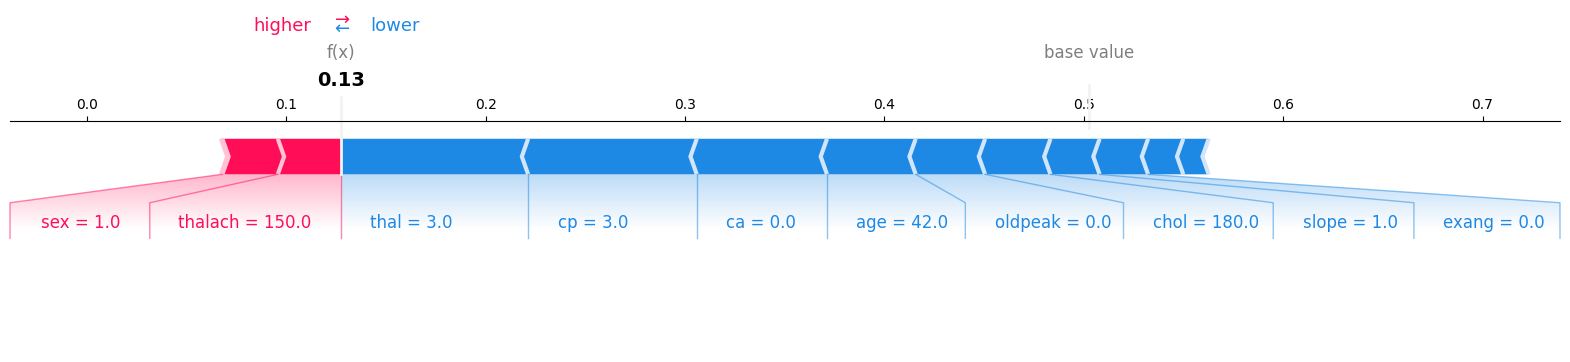


LIME EXPLAINABILITY

LIME Top Contributing Features:
  cp <= -0.18                         → -0.1830
  age <= -0.75                        → -0.0768
  thal <= -0.87                       → -0.0692
  restecg <= -0.99                    → -0.0467
  exang <= -0.69                      → -0.0387
  chol <= -0.71                       → -0.0316


{'Logistic Regression': {'Prediction': 0, 'Probability': np.float64(0.1039)},
 'Random Forest': {'Prediction': 0, 'Probability': np.float64(0.1273)},
 'Keras Neural Network': {'Prediction': 0, 'Probability': np.float32(0.0558)},
 'Final_Prediction': 0}

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import shap
from lime.lime_tabular import LimeTabularExplainer

# ====================== PREPARE EXPLAINERS ======================
print("Preparing SHAP and LIME explainers...")

shap_explainer = shap.TreeExplainer(rf_model)

lime_explainer = LimeTabularExplainer(
    X_train_scaled, 
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    discretize_continuous=True,
    random_state=42
)

print("Explainers ready!\n")

# ====================== ROBUST PREDICTION FUNCTION ======================

def predict_with_full_explainability(patient_data, show_plots=True):
    """
    Predicts using all 3 models + provides ethical analysis + SHAP + LIME
    """
    
    # Convert input
    if isinstance(patient_data, dict):
        input_df = pd.DataFrame([patient_data])
    else:
        input_df = pd.DataFrame([patient_data], columns=X.columns)
    
    input_scaled = scaler.transform(input_df)
    
    # ====================== MODEL PREDICTIONS ======================
    lr_prob = lr_model.predict_proba(input_scaled)[0][1]
    lr_pred = 1 if lr_prob >= 0.5 else 0

    rf_prob = rf_model.predict_proba(input_scaled)[0][1]
    rf_pred = 1 if rf_prob >= 0.5 else 0

    keras_prob = keras_model.predict(input_scaled, verbose=0)[0][0]
    keras_pred = 1 if keras_prob >= 0.5 else 0

    votes = [lr_pred, rf_pred, keras_pred]
    final_pred = 1 if sum(votes) >= 2 else 0

    # ====================== PRINT BASIC RESULTS ======================
    print("\n" + "="*85)
    print("HEART DISEASE PREDICTION + MODEL EXPLAINABILITY")
    print("="*85)

    print(f"\n{'Model':<25} {'Prediction':<18} {'Probability':<12} {'Risk'}")
    print("-" * 85)
    print(f"{'Logistic Regression':<25} {'Heart Disease' if lr_pred==1 else 'No Heart Disease':<18} {lr_prob:.4f}       {'HIGH' if lr_pred==1 else 'LOW'}")
    print(f"{'Random Forest':<25} {'Heart Disease' if rf_pred==1 else 'No Heart Disease':<18} {rf_prob:.4f}       {'HIGH' if rf_pred==1 else 'LOW'}")
    print(f"{'Keras Neural Network':<25} {'Heart Disease' if keras_pred==1 else 'No Heart Disease':<18} {keras_prob:.4f}       {'HIGH' if keras_pred==1 else 'LOW'}")

    print(f"\n>>> Final Majority Vote: {'Heart Disease' if final_pred == 1 else 'No Heart Disease'}")

    # ====================== ETHICAL ANALYSIS ======================
    print("\n" + "="*85)
    print("ETHICAL ANALYSIS (Transparency | Fairness | Accountability)")
    print("="*85)

    print("\n[TRANSPARENCY]")
    print("Logistic Regression : HIGH   → Coefficients are directly interpretable")
    print("Random Forest       : MEDIUM → Feature importance available")
    print("Keras Neural Network: LOW    → Black-box model")

    print("\n[ACCOUNTABILITY]")
    avg_conf = np.mean([abs(p - 0.5) for p in [lr_prob, rf_prob, keras_prob]])
    acc_level = "HIGH" if avg_conf > 0.30 else ("MEDIUM" if avg_conf > 0.15 else "LOW")
    print(f"Level : {acc_level} (Average Confidence = {avg_conf:.2f})")

    print("\n[FAIRNESS]")
    sex = input_df['sex'].values[0]
    if sex == 0:
        print("Gender: Female → Caution: Females are underrepresented in data. Possible gender bias risk.")
    else:
        print("Gender: Male → Acceptable (majority group in training data)")

    # ====================== SHAP EXPLANATION ======================
    print("\n" + "="*85)
    print("SHAP EXPLAINABILITY (Random Forest)")
    print("="*85)

    shap_values = shap_explainer.shap_values(input_scaled)

    # Robust SHAP value extraction
    if isinstance(shap_values, list):
        shap_val = shap_values[1][0]
    else:
        if len(shap_values.shape) == 3:
            shap_val = shap_values[0, :, 1]
        elif len(shap_values.shape) == 2:
            shap_val = shap_values[0]
        else:
            shap_val = shap_values

    shap_df = pd.DataFrame({
        'Feature': X.columns,
        'SHAP Value': shap_val.flatten()
    }).sort_values(by='SHAP Value', key=abs, ascending=False)

    print("\nTop Features Driving This Prediction (SHAP):")
    print(shap_df.head(6).to_string(index=False))

    if show_plots:
        try:
            shap.force_plot(
                shap_explainer.expected_value[1], 
                shap_val, 
                input_df.iloc[0], 
                feature_names=X.columns.tolist(),
                matplotlib=True
            )
            plt.show()
        except:
            print("SHAP force plot could not be displayed.")

    # ====================== LIME EXPLANATION (FIXED) ======================
    print("\n" + "="*85)
    print("LIME EXPLAINABILITY")
    print("="*85)

    exp = lime_explainer.explain_instance(
        input_scaled[0], 
        rf_model.predict_proba, 
        num_features=6
    )

    print("\nLIME Top Contributing Features:")
    for feature, weight in exp.as_list():
        print(f"  {feature:<35} → {weight:+.4f}")

    # ====================== FIXED LIME DISPLAY ======================
    if show_plots:
        try:
            from IPython.display import display, HTML
            display(HTML(exp.as_html()))
        except:
            print("\n(LIME interactive visualization not available in this environment)")
            print("You can still use the text explanation above.")

    return {
        "Logistic Regression": {"Prediction": lr_pred, "Probability": round(lr_prob, 4)},
        "Random Forest": {"Prediction": rf_pred, "Probability": round(rf_prob, 4)},
        "Keras Neural Network": {"Prediction": keras_pred, "Probability": round(keras_prob, 4)},
        "Final_Prediction": final_pred
    }


# ====================== TEST ======================

print("=== Test with Sample from Test Data ===")
sample = X_test.iloc[10]
predict_with_full_explainability(sample)